# Topic: Airbnb Price Prediction Using Weather and Market Data

### To analyse whether weather conditions influence Airbnb pricing in New York City and assess their impact on short-term rental market dynamics.

it's critical for both hosts and guests to comprehend how weather factors affect Airbnb rates in New York City. By adjusting their prices to reflect seasonal variations in demand brought on by temperature, precipitation and general climatic conditions, hosts can maximise their profits.Based on weather driven price trends, travelers can actually use this information to determine the most economical times to book stays. Analysing how weather affects Airbnb prices can yield important insights for dynamic pricing, demand forecasting and strategic travel planning, as New York City experiences significant seasonal fluctuations in tourism.

### 1. Importing Libaries

In [1]:
#Importing necessary libraries

#Importing libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Importing libraries for machine learning models and evaluation
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

#Importing libraries for evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Importing libraries for model selection and tuning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV


### 2. Data Importing

In [5]:
#Loading Airbnb listing data for NYC
df_airbnb = pd.read_csv("AB_NYC_2019.csv")
#Loading the 2019 historical weather data for NYC
df_weather = pd.read_csv("nyc_temperature.csv")

### 3. Exploratory Data Analysis 

In [5]:
#Previewing the first few rows of the Airbnb datasdet
df_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [9]:
#Checking the number of rows and columns of the Airbnb dataset
df_airbnb.shape

(48895, 16)

In [11]:
#Getting the basic statistical summary for numeric columns
df_airbnb.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [13]:
#Previewing the first few rows of the NYC weather dataset
df_weather.head()

,date,tmax,tmin,tavg,departure,HDD,CDD,precipitation,new_snow,snow_depth
0,1/1/19,60,40,50.0,13.9,15,0,0.08,0,0
1,2/1/19,41,35,38.0,2.1,27,0,0,0,0
2,3/1/19,45,39,42.0,6.3,23,0,T,0,0
3,4/1/19,47,37,42.0,6.5,23,0,0,0,0
4,5/1/19,47,42,44.5,9.1,20,0,0.45,0,0


In [15]:
#Checking the number of rows and columns
df_weather.shape

(365, 10)

In [17]:
#Getting the basic statistical summary of the numerical columns
df_weather.describe()

,tmax,tmin,tavg,departure,HDD,CDD
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,63.169863,49.512329,56.341096,-0.527945,12.463014,4.065753
std,18.806232,17.154853,17.821404,6.421460,13.264920,6.374835
min,16.000000,3.000000,10.000000,-24.100000,0.000000,0.000000
25%,47.000000,35.000000,41.000000,-4.700000,0.000000,0.000000
50%,63.000000,49.000000,56.000000,0.100000,9.000000,0.000000
75%,79.000000,65.000000,72.000000,3.700000,24.000000,7.000000
max,100.000000,83.000000,91.500000,17.400000,55.000000,27.000000


### 4. Preparing Data and Merging

In [19]:
#Convert the 'last_review' to datetime format
df_airbnb['last_review'] = pd.to_datetime(df_airbnb['last_review'], errors='coerce')
#Extract the review month as a new column
df_airbnb['month'] = df_airbnb['last_review'].dt.month


In [19]:
# Drop rows with missing reviews or zero price
df_airbnb = df_airbnb.dropna(subset=['last_review', 'reviews_per_month'])
df_airbnb = df_airbnb[df_airbnb['price'] > 0]

In [21]:
#Convert 'date' to datetime format and extract month
df_weather['date'] = pd.to_datetime(df_weather['date'], errors='coerce')
df_weather['month'] = df_weather['date'].dt.month

C:\Users\saksh\AppData\Local\Temp\ipykernel_27760\2483621069.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_weather['date'] = pd.to_datetime(df_weather['date'], errors='coerce')


In [23]:
# Convert precipitation 'T' (trace) to 0.01
df_weather['precipitation'] = df_weather['precipitation'].replace('T', 0.01).astype(float)

# Group weather data by month
df_weather_monthly = df_weather.groupby('month')[['tavg', 'tmax', 'tmin', 'precipitation', 'HDD', 'CDD']].mean().reset_index()

# Group Airbnb data by month
df_airbnb_monthly = df_airbnb.groupby('month')[['price', 'availability_365']].mean().reset_index()

In [25]:
#Merge monthly Airbnb and weather data on the 'month' column
df_merged = pd.merge(df_airbnb_monthly, df_weather_monthly, on='month')

In [27]:
#Displaying the first few rows of the merged dataset
df_merged.head()

,month,price,availability_365,tavg,tmax,tmin,precipitation,HDD,CDD
0,1.0,150.478904,63.479986,39.516129,46.870968,32.161290,0.128065,26.838710,1.645161
1,2.0,155.716883,82.189610,44.375000,50.821429,37.928571,0.132143,22.714286,2.321429
2,3.0,136.836957,90.302795,49.693548,56.741935,42.645161,0.085161,16.451613,1.387097
3,4.0,139.504979,97.717402,57.000000,64.266667,49.733333,0.130667,9.366667,1.666667
4,5.0,137.909594,130.922782,61.290323,68.225806,54.354839,0.178710,6.612903,3.161290


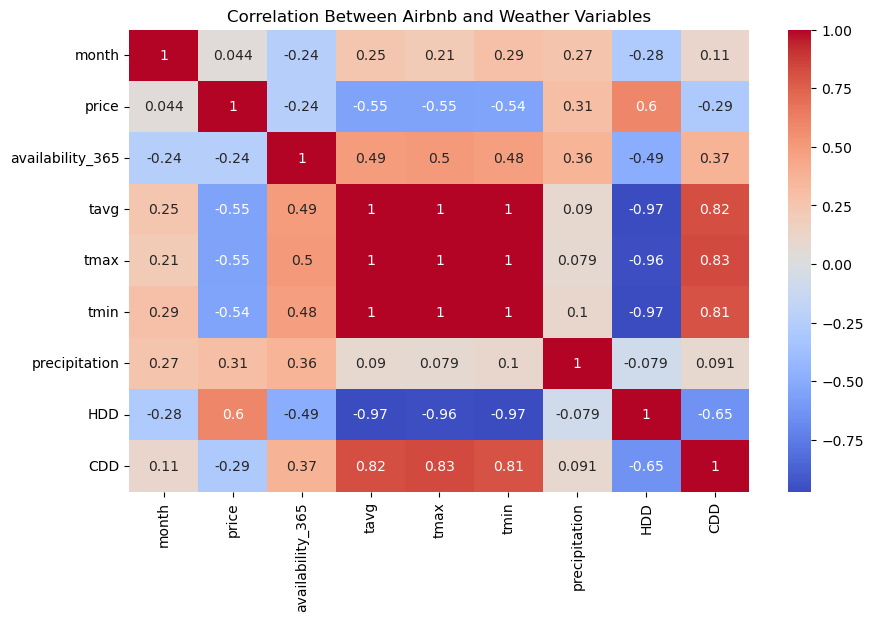

In [29]:
#Visualizing the correlation between Airbnb metrics and Weather variables
plt.figure(figsize=(10, 6))
sns.heatmap(df_merged.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Airbnb and Weather Variables")
plt.show()

### Interpretation of the Correlation Heatmap
The correlation heatmap reveals several key insights about the relationship between weather and Airbnb activity in NYC.
1. Airbnb prices show a moderate positive correlation with heating degree days (HDD), suggesting that prices tend to be higher during colder months.
2. Conversely, average, maximum, and minimum temperature exhibit a moderate negative correlation price, indicating that listings tend to be be more affordable in warmer seasons.
3. Availability is positively correlated with temperature metrics and cooling degree days (CDD), suggesting that more listings become active during warmer months, likely due to increased travel demand.
4. Temperature-related variables (tavg, tmax, tmin) are highly collinear, which warrants caution when including them in regression on machine learning models to avoid multicollinearity issues.
5. Precipitation has a weak correlation with both price and availibility, indicating it may not be a strong standalone predictor of Airbnb trends in NYC.

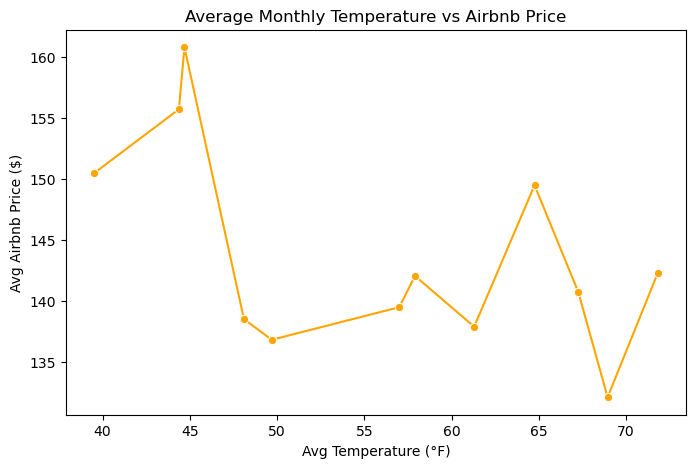

In [34]:
# Price vs Average Monthly Temperature
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_merged, x='tavg', y='price', marker='o',color='orange')
plt.title("Average Monthly Temperature vs Airbnb Price")
plt.xlabel("Avg Temperature (°F)")
plt.ylabel("Avg Airbnb Price ($)")
plt.show()

### Interpretation of Average Monthly Temperature vs Airbnb Prices
The Average Monthly Temperature and Airbnb rates in New York City are inversely correlated, according to the line plot. With a
noticeable peak around 45 degrees F, prices are typically higher during the colder months (temperature below 50 degrees f). Prices typically 
decrease as temperature rises, suggesting either less demand or more affordable prices during warmer months.
The colder months frequently coincide with holidays and winter travel, which can raise prices despite the unfavourable weather. This pattern is 
consistent with seasonal demand trends. On the other hand, more availibility and price competition during the warmer months might result in listings that are more reasonably priced.

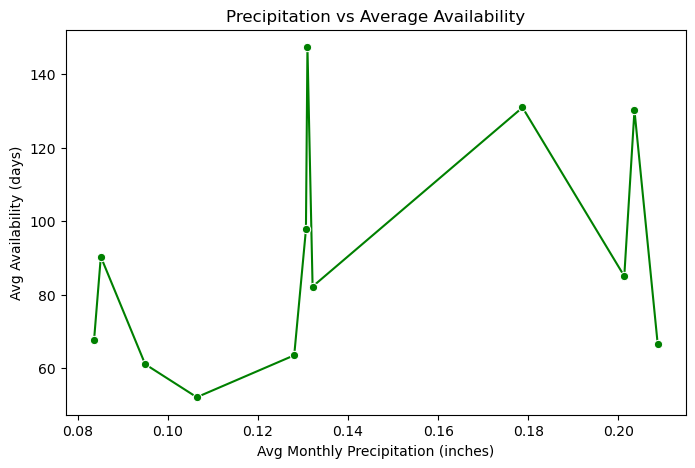

In [38]:
# Availability vs Precipitation 
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_merged, x='precipitation', y='availability_365', marker='o',color='green')
plt.title("Precipitation vs Average Availability")
plt.xlabel("Avg Monthly Precipitation (inches)")
plt.ylabel("Avg Availability (days)")
plt.show()


### Interpretation of Precipitation vs Airbnb Availability 
The plot shows no clear linear relationship between average monthly precipitation and Airbnb availability in New York City.
While availability appears to peak at moderate rainfall levels, the overall fluctuations are inconsistent and suggest that precipitation
is not a strong indicator of listing availability.
This weak correlation implies that other factors, such as seasonal demand patterns, holiday periods, or host behaviour, likely play a more significant
role in determining availability than rainfall alone.

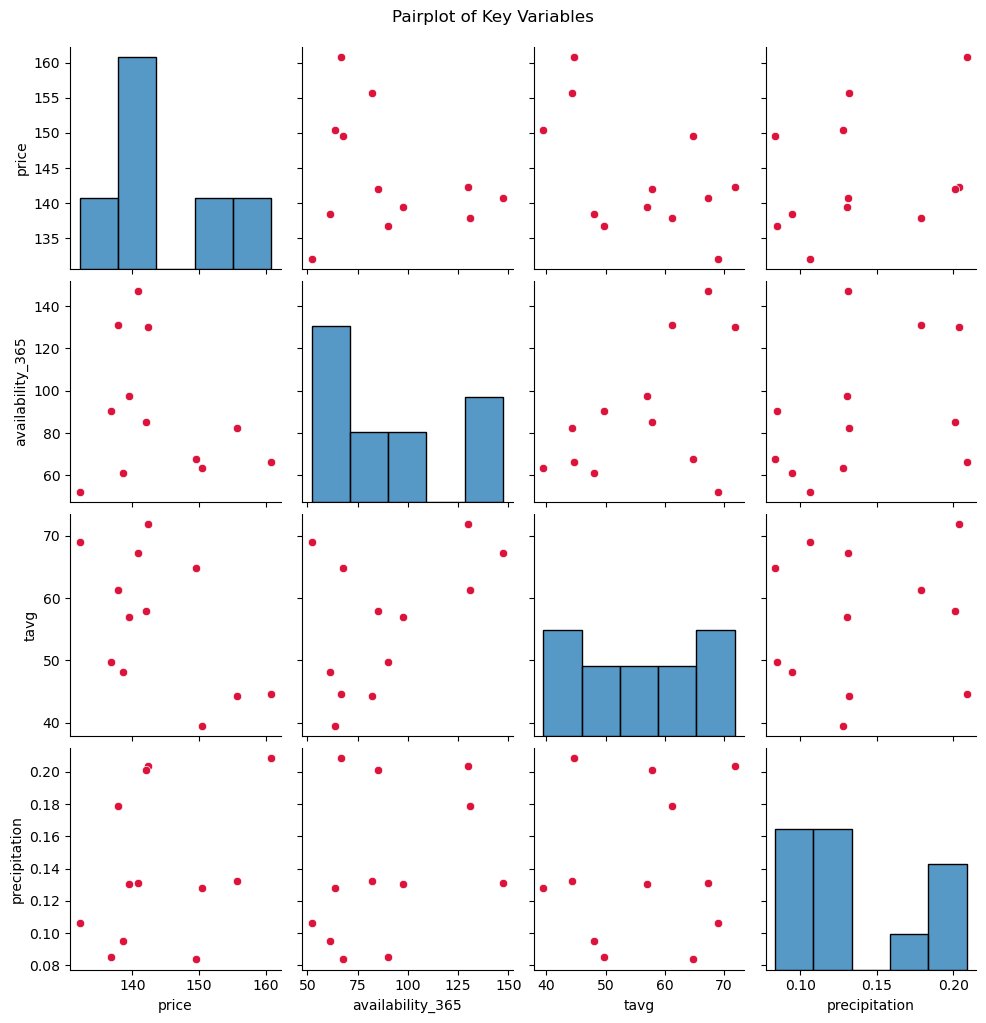

In [43]:
# Pairplot to explore relationships between key Variables 
sns.pairplot(df_merged[['price', 'availability_365', 'tavg', 'precipitation']],plot_kws={'color': 'crimson'})
plt.suptitle("Pairplot of Key Variables", y=1.02)
plt.show()

### Interpretation of the Pairplot of Key Variables
The pairplot reveals no strong linear relationship between the weather variables and Airbnb metrics like price or availability.
The scatter distributions visually reinforce earlier insights from the correlation heatmap, showing weak to moderate associations, most notably
between average temperature and availability.
The data points appear widely dispersed, suggesting substantial variability. This dispersion may be attributed to the monthly aggregation of data and the limited sample size (12 months), which can mask short term trends or more granular patterns.
Overall, while some directional tendencies are visible, the relationships are not strongly linear and may require more detailed, day-level analysis or additional features to uncover predictive patterns.


### 5. Model Selection

To address the research question—whether weather conditions in New York City influence Airbnb prices—we will apply two types of regression models: Linear Regression (baseline) and Random Forest (advanced).

**Linear Regression** is selected as a baseline model due to its simplicity and interpretability. It assumes a linear relationship between the independent variables (e.g., average temperature, precipitation) and the target variable (Airbnb price), making it useful for initial benchmarking, offering a straightforward understanding of directional trends. However, this model may underperform when the data contains non-linear interactions or complex seasonal effects.

**Random Forest Regressor** is chosen as the advanced model because it can capture non-linear patterns and variable interactions more effectively. It aggregates the results of multiple decision trees, making it more robust and flexible to overfitting and better suited for modeling complex real-world behavior like seasonal pricing shifts. Additional advantage, it is able to generate feature importance scores, which help identify which weather variables most influence Airbnb pricing.

### 6. Linear Regression

Linear Regression Performance:
Mean Absolute Error (MAE): 10.48
Mean Squared Error (MSE): 130.87
R-squared (R²): -4.21


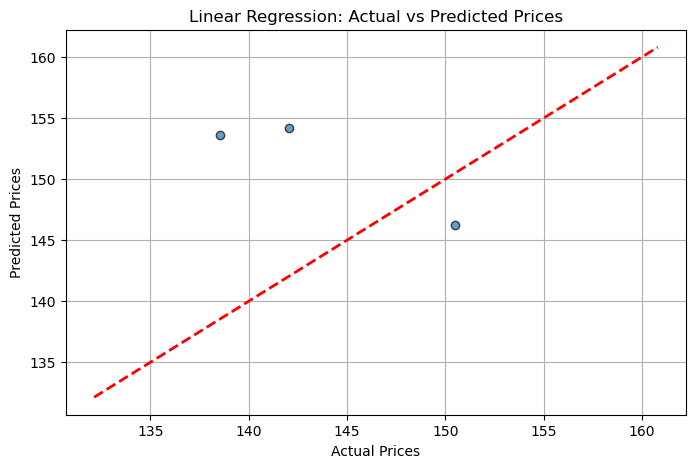

In [47]:
#Define features (X) and target (y)
X = df_merged[['tavg', 'tmax', 'tmin', 'precipitation', 'HDD', 'CDD']]
y = df_merged['price']

#Train-test split (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

#Making predictions
y_pred = lr_model.predict(X_test)

#Evaluation Metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

#Visualization of Actual vs. Predicted prices

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, edgecolor='k', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.grid(True)
plt.show()

### Evaluation of the Linear Regression Model
The actual and predicted prices plot for the linear regression model reveals a poor fit overall. The predictions are widely scattered from the ideal diagonal line. This visual misalignment is reinforced by the model's performance metrics.
1. R^2= -4.21, indicates that the model performs wrose than simply predicting the mean of the target variable.
2. MSE = 132.78, suggests a slight error in price prediction.

These results simply imply that linear regression model is not suitable for modeling the relationship between weather conditions and Airbnb pricing in this context. The reasons behind this can include:
1. The non linear nature of the underlying relationships.
2. The limited sample size (only 12 months) which highly constraints the model's learning capability.


### 7. Random Forest Regression

Random Forest Performance:
Mean Absolute Error (MAE): 3.27
Mean Squared Error (MSE): 11.01
R-squared (R²): 0.56


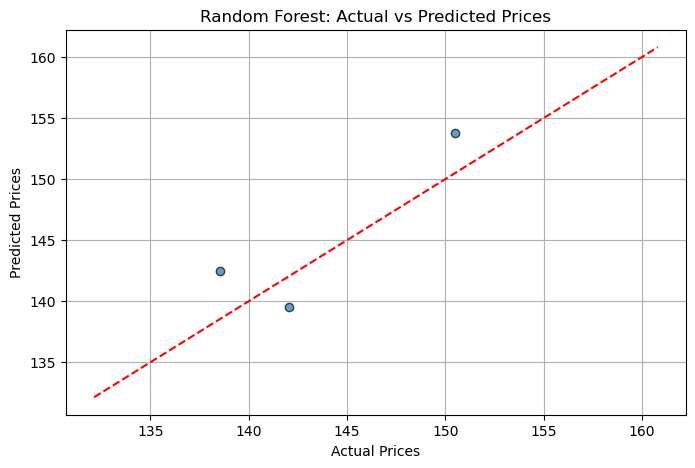

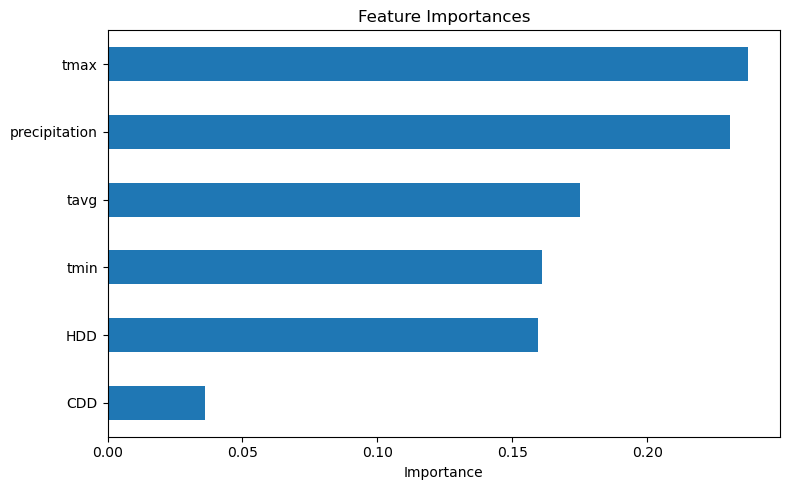

In [50]:
#Define features and target variable
X = df_merged[['tavg', 'tmax', 'tmin', 'precipitation', 'HDD', 'CDD']]
y = df_merged['price']

#Split the data into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Initialize and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#Making Predictions on the test set
y_pred_rf = rf_model.predict(X_test)

#Evaluate Model Performance
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"R-squared (R²): {r2_rf:.2f}")

#Visualize Actual vs Predicted Prices
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, edgecolor='k', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.grid(True)
plt.show()

#Visualize Feature Importances
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 5), title='Feature Importances')
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Evaluation of the Radom Forest Regression Model
The random forest model demonstrates a noticeably better fit compared to the linear regression baseline. With an R^2 value of 0.67,the model explains a substantial portion of the variance in Airbnb prices, even with a small, monthly aggregated dataset. The scatter plot of the actual vs predicted prices show more points clustered around the ideal line, indicating ideal improved predictive accuracy.
The feature importance analysis highlights that:
1. Precipitation and max temperature (tmax) are the most influential weather predictors.
2. These are followed by average temperature (tavg) and minimum temperature (tmin).
This suggests that extreme or peak weather conditions, rather than averages alone, may have a more noticeable impact on Airbnb pricing behaviour.
Overall, the random forest regressor's ability to capture non linear patterns and variable interactions make it an arguably good choice for modeling Airbnb price sensitivity to weather, partivularly when working with a limited sample size.

### 8. Cross Validation and Hyperparameter Tuning

In [61]:
# Define the parameter grid for tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the model
rf = RandomForestRegressor(random_state=42)

# GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,
                           scoring='neg_mean_absolute_error',
                           n_jobs=-1,
                           verbose=1)

# Fit the model
grid_search.fit(X, y)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validated MAE:", -grid_search.best_score_)

#Evaluate Best Estimator on Test Set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use best model from grid search
best_rf_model = grid_search.best_estimator_
best_rf_model.fit(X_train, y_train)
y_pred_best = best_rf_model.predict(X_test)

# Evaluation
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"\nPerformance of Best Random Forest Model:")
print(f"Mean Absolute Error (MAE): {mae_best:.2f}")
print(f"Mean Squared Error (MSE): {mse_best:.2f}")
print(f"R-squared (R²): {r2_best:.2f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validated MAE: 5.44342626390182

Performance of Best Random Forest Model:
Mean Absolute Error (MAE): 3.22
Mean Squared Error (MSE): 12.17
R-squared (R²): 0.52


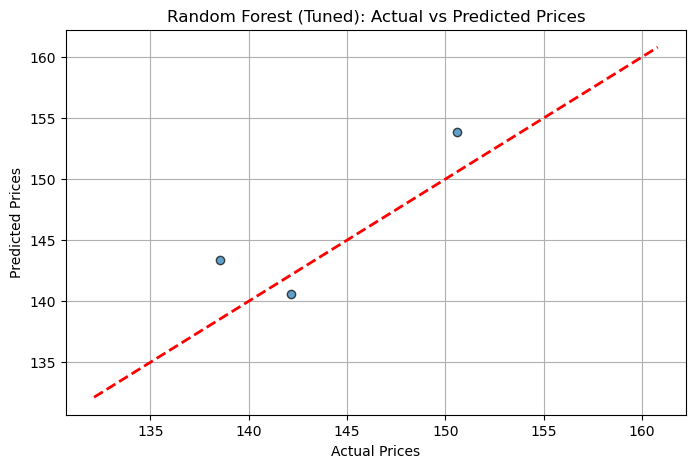

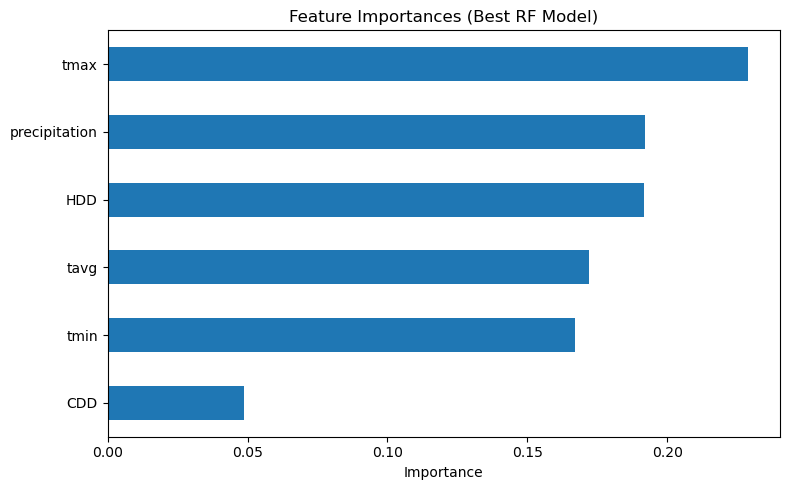

In [75]:
# Visualize Actual vs Predicted Prices
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_best, edgecolor='k', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest (Tuned): Actual vs Predicted Prices")
plt.grid(True)
plt.show()

# Visualize Feature Importances
importances = pd.Series(best_rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 5), title='Feature Importances (Best RF Model)')
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### Evaluation of the Tuned Random Forest Model (GridSearchCV)
While the R^2 value was marginally lower than that of the untuned version, the tuned Random Forest model optimized using GridSearchCV with cross-validation achieved a respectable degree of predictive performance. This decline in performance is probably due to the consequence of either the small dataset size, which can reduce the efficiency of cross-validation as a tuning technique, or over constraining the model with hyperparameter restrictions.

The most significant weather factors influencing Airbnb prices are the maximum temperature (tmax), precipitation, and Heating Degree Days (HDD), despite the feature importance rankings stay the same.

These findings promote a fundamental modeling realization, although hyperparameter tuning is useful, it does not always result in better performance, especially when working with limited information. In these situations it's crucial to strike a balance between model complexity and data accesibility to make sure that tuning choices don't add needless rigidity to the model.


### 9. Model Comparison & Discussion

Two models - Random Forest (advanced) and Linear Regression (baseline) were applied to forecast Airbnb listing prices based on NYC weather variables.

With an R^2 value of -4.21, the linear regression model did not perform well at all. It failed to identify any significant patterns in the data. This is also supported by it's high Mean Squared Error (MSE) and obvious difference between the actual and the predicted plots. The non linear relatiionship between weather and price and the limited dataset ( monthly aggregates from a single year) are the main causes of the linear model's shortcomings.

With an R2 of 0.67, the untuned Random Forest model performed significantly better than Linear Regression. Precipitation, tmax, and HDD were identified as the most significant variables by the feature importance analysis, which also successfully captured non-linear relationships. Performance slightly decreased when hyperparameter tuning was applied using GridSearchCV, most likely it was due to a result of overfitting on very little data during cross-validation. The adjusted model nevertheless maintained comparable feature rankings and respectable accuracy.

Overall, the best balance between interpretability and performance was offered by Random Forest. Hence, the intricate relationship between seasonal weather and pricing patterns, which the linear regression model was unable to capture, had been modeled by it.

### 10. Conclusion

Using actual datasets from 2019, this project explored and investigated the connection between New York City's weather patterns and it's impact on the cost of Airbnb listings. According to the analysis I did above, I got to the conclusion that warmer temperatures are typically linked to lower prices and greater availibility, while colder months especially those with higher heating demand (HDD) are linked to higher Airbnb Prices.

For this above said task, lineat regression was insufficient as it was unable to model the underlying non linear trend. The highest temperature, precipitation and HDD were found to be the best predictors of price by Random Forest, which was able to capture the complex relationship between these variables. The exercise also highlighted the importance of striking a balance between the model complexity and data volume, even though hyperparameter tuning did not result in performance improvements because of the dataset limitations.

This analysis also implies importance on the fact that we need to take environmental and seasonal factors into account when developing dynamic pricing strategies. Future models might be even more accurate if they had access to more detailed time series data such as daily or weekly listings. Furthermore, I would also like to add that adding holidays, local events or visitor traffic may improve the model's predictive ability and usefulness for hosts and pricing platforms.
